In [ ]:
# # Fraud Detection Using Machine Learning

# ## Project Objective

# The objective of this project is to build a production-ready Fraud Detection Machine Learning pipeline capable of identifying fraudulent credit card transactions.

# Unlike beginner machine learning projects that focus only on achieving high accuracy, this project follows industry-standard practices including:

# - Comprehensive Exploratory Data Analysis (EDA)
# - Proper Data Cleaning
# - Prevention of Data Leakage
# - Correct Handling of Imbalanced Data
# - Feature Engineering
# - Preprocessing using reusable pipelines
# - Training Multiple Machine Learning Models
# - Hyperparameter Optimization
# - Threshold Optimization
# - Model Interpretation
# - Saving a Complete Deployment Pipeline

# ---

# ## Dataset

# The dataset contains anonymized credit card transactions.

# Target Variable:

# - **Class = 0** → Genuine Transaction
# - **Class = 1** → Fraudulent Transaction

# Since fraudulent transactions are extremely rare, this project focuses on improving Precision, Recall, F1 Score and ROC-AUC instead of relying only on Accuracy.

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# -------------------------
# Data Manipulation
# -------------------------
import numpy as np
import pandas as pd

# -------------------------
# Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Ignore Warnings
# -------------------------
import warnings
warnings.filterwarnings("ignore")

# -------------------------
# Display Settings
# -------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_style("whitegrid")

# -------------------------
# Train-Test Split
# -------------------------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

# -------------------------
# Preprocessing
# -------------------------
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from imblearn.pipeline import Pipeline

# -------------------------
# Imbalanced Data
# -------------------------
from imblearn.over_sampling import SMOTE

# -------------------------
# Machine Learning Models
# -------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# -------------------------
# Evaluation Metrics
# -------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

# -------------------------
# Save Model
# -------------------------
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

DATA_PATH = "./sample_data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully!")

print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset Loaded Successfully!

Rows    : 7,973
Columns : 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

display(df.head())

print("\nShape")
display(df.shape)

print("\nColumn Names")
display(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nDuplicate Rows")
display(df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe())

print("\nTarget Distribution")
display(df["Class"].value_counts())

print("\nTarget Percentage")
display(round(df["Class"].value_counts(normalize=True)*100,4))

DATASET INFORMATION


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



Shape


(7973, 31)


Column Names


...

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7973.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000
mean,4257.151261,-0.299740,0.295226,0.899355,0.215736,-0.025285,0.157286,-0.026445,-0.070525,0.655244,-0.164082,0.635874,-1.022368,0.690562,0.561420,-0.067884,-0.035773,0.279405,-0.060423,-0.055885,0.043110,-0.053715,-0.165799,-0.035174,0.025977,0.088893,0.020256,0.016150,0.001161,65.413540,0.003136
std,3198.964299,1.498341,1.283914,1.090297,1.447057,1.167218,1.325015,1.063709,1.332568,1.156618,1.084482,1.131918,1.510336,1.238190,1.137602,0.983633,0.841755,0.852101,0.791354,0.811364,0.605707,0.953498,0.654858,0.488322,0.601760,0.427505,0.517409,0.403570,0.275976,194.911169,0.055915
min,0.000000,-23.066842,-25.640527,-12.389545,-4.657545,-32.092129,-7.574798,-12.968670,-23.632502,-3.878658,-7.454841,-2.595325,-10.912819,-3.389510,-11.736729,-4.152532,-7.552342,-12.598419,-5.131549,-4.932733,-13.276034,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.054085,0.000000,0.000000
25%,1531.000000,-1.046362,-0.237359,0.372435,-0.687521,-0.630525,-0.655399,-0.517733,-0.199794,-0.085635,-0.673111,-0.165456,-2.273429,-0.212730,-0.050796,-0.654293,-0.547605,-0.257929,-0.506580,-0.548056,-0.147399,-0.271837,-0.581473,-0.182989,-0.340419,-0.161009,-0.363180,-0.063198,-0.019081,4.617500,0.000000
50%,3635.000000,-0.416341,0.335446,0.948695,0.223379,-0.107337,-0.148669,0.004732,0.016128,0.613170,-0.258630,0.623438,-1.042323,0.710567,0.565118,0.057160,0.023556,0.237956,-0.027308,-0.051841,-0.007344,-0.130344,-0.167048,-0.046107,0.089606,0.115418,-0.015260,0.007101,0.018443,15.950000,0.000000
75%,6662.000000,1.122758,0.950582,1.597949,1.131542,0.405082,0.555200,0.527353,0.307111,1.294087,0.243533,1.416838,0.303311,1.638147,1.400274,0.596297,0.517720,0.751774,0.416734,0.468180,0.173362,0.044823,0.250886,0.086806,0.421015,0.361249,0.329322,0.144700,0.080563,54.910000,0.000000
max,10981.000000,1.685314,8.261750,4.101716,7.380245,11.974269,21.393069,34.303177,3.877662,10.392889,12.259949,7.620089,3.774837,4.465413,5.748734,3.635042,4.087802,6.739384,3.042493,3.097749,8.012574,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,4.173387,4.860769,7712.430000,1.000000



Target Distribution


,count
Class,
0.0,7947
1.0,25



Target Percentage


,proportion
Class,
0.0,99.6864
1.0,0.3136


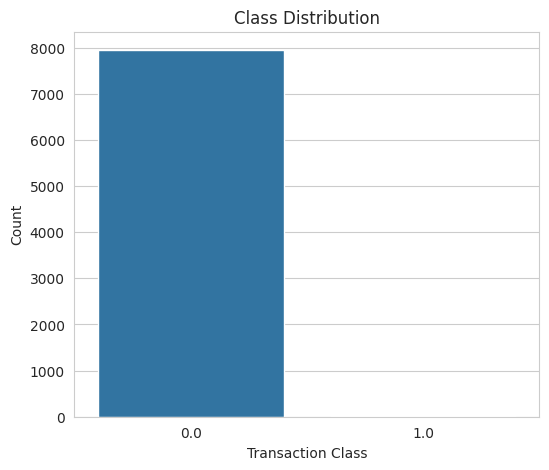

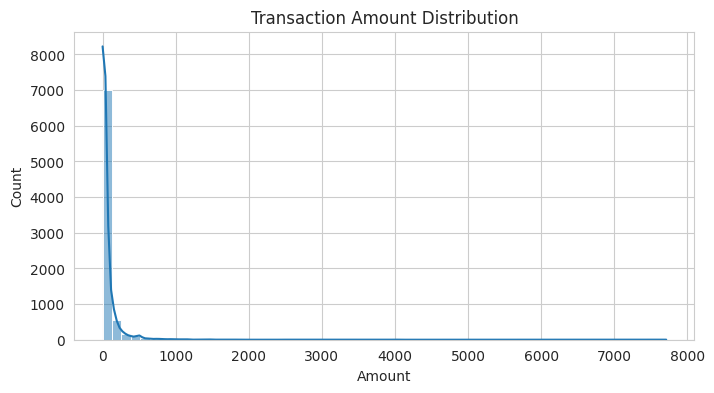

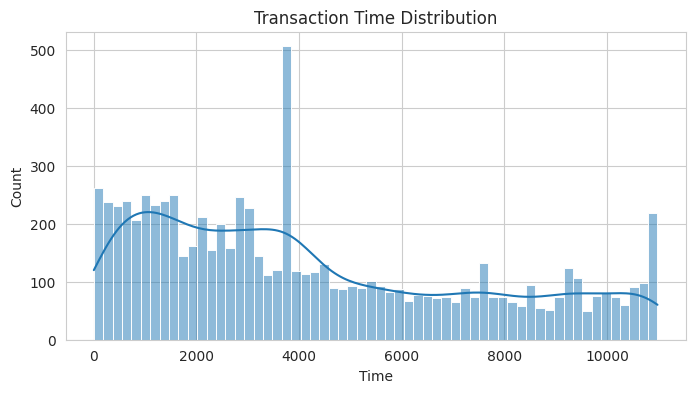

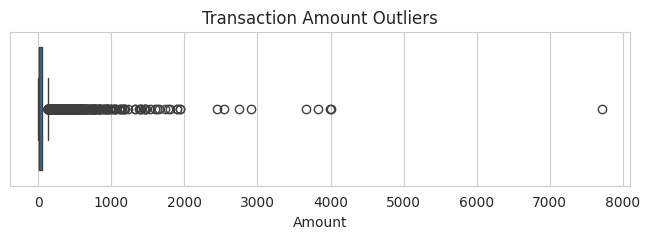

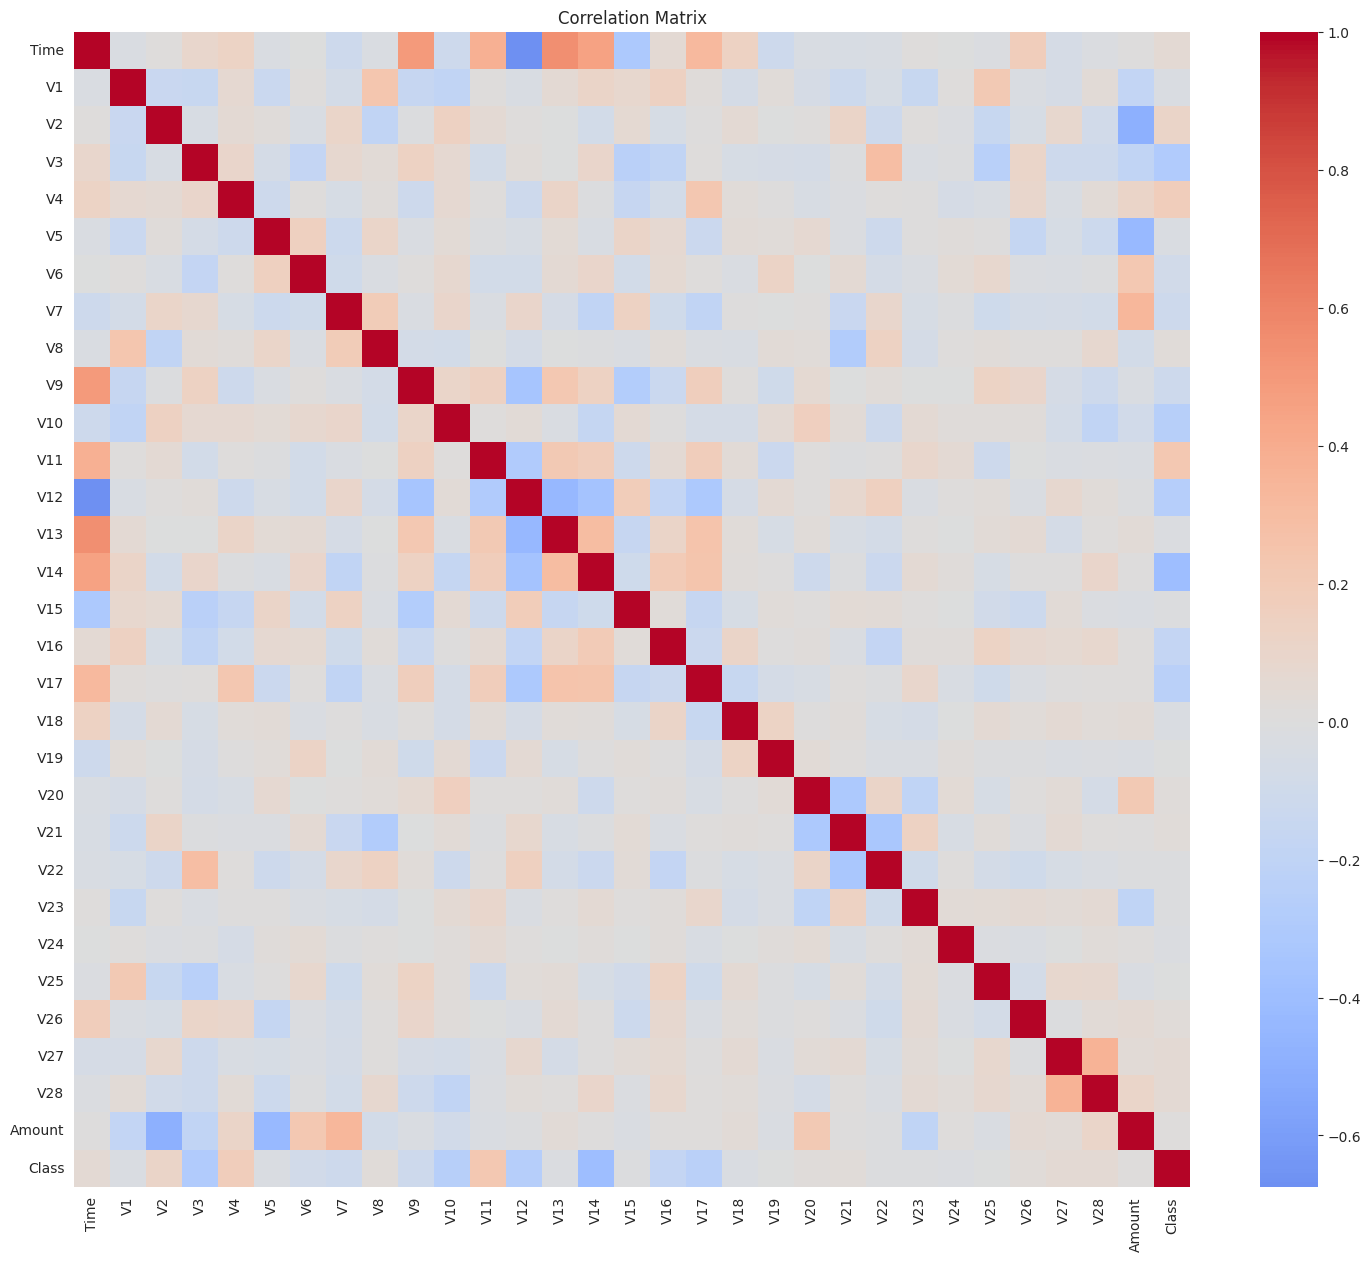

In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

# -------------------------
# Class Distribution
# -------------------------

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Count")

plt.show()

# -------------------------
# Amount Distribution
# -------------------------

plt.figure(figsize=(8,4))

sns.histplot(
    df["Amount"],
    bins=60,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

# -------------------------
# Time Distribution
# -------------------------

plt.figure(figsize=(8,4))

sns.histplot(
    df["Time"],
    bins=60,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.show()

# -------------------------
# Amount Boxplot
# -------------------------

plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Amount"]
)

plt.title("Transaction Amount Outliers")

plt.show()

# -------------------------
# Correlation Heatmap
# -------------------------

plt.figure(figsize=(18,15))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# ============================================================
# EDA INSIGHTS
# ============================================================

print("""
Key Observations

1. Dataset is highly imbalanced.

2. Fraud transactions represent a very small percentage.

3. No missing values.

4. Numerical features are already anonymized (V1–V28).

5. Amount contains significant outliers.

6. Time is measured as seconds from the first transaction.

7. Feature engineering opportunities are limited because original
   business information has been anonymized.

8. Accuracy alone is NOT an appropriate metric for this problem.

We will primarily optimize:

• Precision
• Recall
• F1 Score
• ROC-AUC
""")


Key Observations

1. Dataset is highly imbalanced.

2. Fraud transactions represent a very small percentage.

3. No missing values.

4. Numerical features are already anonymized (V1–V28).

5. Amount contains significant outliers.

6. Time is measured as seconds from the first transaction.

7. Feature engineering opportunities are limited because original
   business information has been anonymized.

8. Accuracy alone is NOT an appropriate metric for this problem.

We will primarily optimize:

• Precision
• Recall
• F1 Score
• ROC-AUC



In [ ]:
# ============================================================
# DATA CLEANING
# ============================================================

print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

# -------------------------
# Initial Shape
# -------------------------

print(f"Original Shape : {df.shape}")

# -------------------------
# Remove Missing Values
# -------------------------

missing_before = df.isnull().sum().sum()

print(f"\nMissing Values Before : {missing_before}")

df = df.dropna()

missing_after = df.isnull().sum().sum()

print(f"Missing Values After  : {missing_after}")

# -------------------------
# Remove Duplicate Rows
# -------------------------

duplicates_before = df.duplicated().sum()

print(f"\nDuplicate Rows Before : {duplicates_before}")

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print(f"Duplicate Rows After  : {duplicates_after}")

# -------------------------
# Convert Target to Integer
# -------------------------

df["Class"] = df["Class"].astype(int)

print("\nTarget Data Type")

print(df["Class"].dtype)

print("\nFinal Shape")

print(df.shape)

DATA CLEANING
Original Shape : (7973, 31)

Missing Values Before : 16
Missing Values After  : 0

Duplicate Rows Before : 39
Duplicate Rows After  : 0

Target Data Type
int64

Final Shape
(7933, 31)


In [ ]:
# ============================================================
# SPLIT FEATURES AND TARGET
# ============================================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("=" * 70)
print("FEATURES & TARGET")
print("=" * 70)

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

print("\nTarget Distribution")

print(y.value_counts())

print("\nTarget Percentage")

print(round(y.value_counts(normalize=True) * 100, 4))

FEATURES & TARGET
Feature Matrix Shape : (7933, 30)
Target Shape         : (7933,)

Target Distribution
Class
0    7908
1      25
Name: count, dtype: int64

Target Percentage
Class
0    99.6849
1     0.3151
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print("\nTraining Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

print("\nTraining Percentage")

print(round(y_train.value_counts(normalize=True) * 100, 4))

print("\nTesting Percentage")

print(round(y_test.value_counts(normalize=True) * 100, 4))

TRAIN TEST SPLIT
Training Samples : 6,346
Testing Samples  : 1,587

Training Class Distribution
Class
0    6326
1      20
Name: count, dtype: int64

Testing Class Distribution
Class
0    1582
1       5
Name: count, dtype: int64

Training Percentage
Class
0    99.6848
1     0.3152
Name: proportion, dtype: float64

Testing Percentage
Class
0    99.6849
1     0.3151
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

# -------------------------
# Log Transform Amount
# -------------------------

X_train["Log_Amount"] = np.log1p(X_train["Amount"])
X_test["Log_Amount"] = np.log1p(X_test["Amount"])

# -------------------------
# High Amount Transaction
# Threshold learned ONLY from training data
# -------------------------

amount_threshold = X_train["Amount"].quantile(0.95)

X_train["High_Amount"] = (
    X_train["Amount"] > amount_threshold
).astype(int)

X_test["High_Amount"] = (
    X_test["Amount"] > amount_threshold
).astype(int)

print("=" * 70)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 70)

print(f"95th Percentile Amount : {amount_threshold:.2f}")

print("\nNew Features Added")

print([
    "Log_Amount",
    "High_Amount"
])

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

FEATURE ENGINEERING COMPLETED
95th Percentile Amount : 274.90

New Features Added
['Log_Amount', 'High_Amount']

Training Shape : (6346, 32)
Testing Shape  : (1587, 32)


In [ ]:
# ============================================================
# PREPROCESSING
# ============================================================

print("=" * 70)
print("PREPROCESSING")
print("=" * 70)

# -------------------------
# Numerical Columns
# -------------------------

numeric_features = X_train.columns.tolist()

# -------------------------
# Standard Scaler
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

print("\nTraining Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

PREPROCESSING
Scaling Completed

Training Shape : (6346, 32)
Testing Shape  : (1587, 32)


In [ ]:
# ============================================================
# HANDLE IMBALANCED DATA (SMOTE)
# ============================================================

print("=" * 70)
print("SMOTE")
print("=" * 70)

print("Before SMOTE")
print(y_train.value_counts())

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

print("\nTraining Shape After SMOTE")
print(X_train_smote.shape)

SMOTE
Before SMOTE
Class
0    6326
1      20
Name: count, dtype: int64

After SMOTE
Class
0    6326
1    6326
Name: count, dtype: int64

Training Shape After SMOTE
(12652, 32)


In [ ]:
# ============================================================
# SCALE SMOTE DATA
# ============================================================

print("=" * 70)
print("SCALING SMOTE DATA")
print("=" * 70)

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("SMOTE Training Shape :", X_train_smote_scaled.shape)
print("Testing Shape        :", X_test_scaled.shape)

SCALING SMOTE DATA
SMOTE Training Shape : (12652, 32)
Testing Shape        : (1587, 32)


In [ ]:
# ============================================================
# MODEL TRAINING
# ============================================================

print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Define Models
# ------------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

}

trained_models = {}

# ------------------------------------------------------------
# Train Models
# ------------------------------------------------------------

for model_name, model in models.items():

    print(f"Training {model_name}...")

    # Models that require scaled data
    if model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_smote,
            y_train_smote
        )

    # Tree models and Naive Bayes
    else:

        model.fit(
            X_train_smote,
            y_train_smote
        )

    trained_models[model_name] = model

print("\nTraining Completed Successfully!")

print("\nModels Trained:")

for model in trained_models:
    print("-", model)

MODEL TRAINING
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Naive Bayes...
Training KNN...
Training SVM...
Training XGBoost...

Training Completed Successfully!

Models Trained:
- Logistic Regression
- Decision Tree
- Random Forest
- Naive Bayes
- KNN
- SVM
- XGBoost


In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

results = []

for model_name, model in trained_models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # -------------------------------------------------------
    # Select Correct Test Data
    # -------------------------------------------------------

    if model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        X_test_used = X_test_scaled

    else:

        X_test_used = X_test

    # -------------------------------------------------------
    # Predictions
    # -------------------------------------------------------

    y_pred = model.predict(X_test_used)

    y_prob = model.predict_proba(X_test_used)[:, 1]

    # -------------------------------------------------------
    # Metrics
    # -------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # -------------------------------------------------------
    # Confusion Matrix
    # -------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print("\nConfusion Matrix\n")
    print(cm)

    # -------------------------------------------------------
    # Classification Report
    # -------------------------------------------------------

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # -------------------------------------------------------
    # Metrics
    # -------------------------------------------------------

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })

print("\nEvaluation Completed Successfully!")

MODEL EVALUATION

Logistic Regression

Confusion Matrix

[[1579    3]
 [   5    0]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1582
           1       0.00      0.00      0.00         5

    accuracy                           0.99      1587
   macro avg       0.50      0.50      0.50      1587
weighted avg       0.99      0.99      0.99      1587

Accuracy  : 0.9950
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.3966

Decision Tree

Confusion Matrix

[[1449  133]
 [   1    4]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1582
           1       0.03      0.80      0.06         5

    accuracy                           0.92      1587
   macro avg       0.51      0.86      0.51      1587
weighted avg       1.00      0.92      0.95      1587

Accuracy  : 0.9156
Precision : 0.0292
Recall    : 0.8000
F

In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df = results_df.round(4)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(results_df)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.9994,1.0000,0.8,0.8889,1.0000
1,XGBoost,0.9950,0.3846,1.0,0.5556,0.9999
2,Decision Tree,0.9156,0.0292,0.8,0.0563,0.8580
3,Logistic Regression,0.9950,0.0000,0.0,0.0000,0.3966
4,Naive Bayes,0.9931,0.0000,0.0,0.0000,0.4968
5,KNN,0.9968,0.0000,0.0,0.0000,0.5000
6,SVM,0.9968,0.0000,0.0,0.0000,0.5032


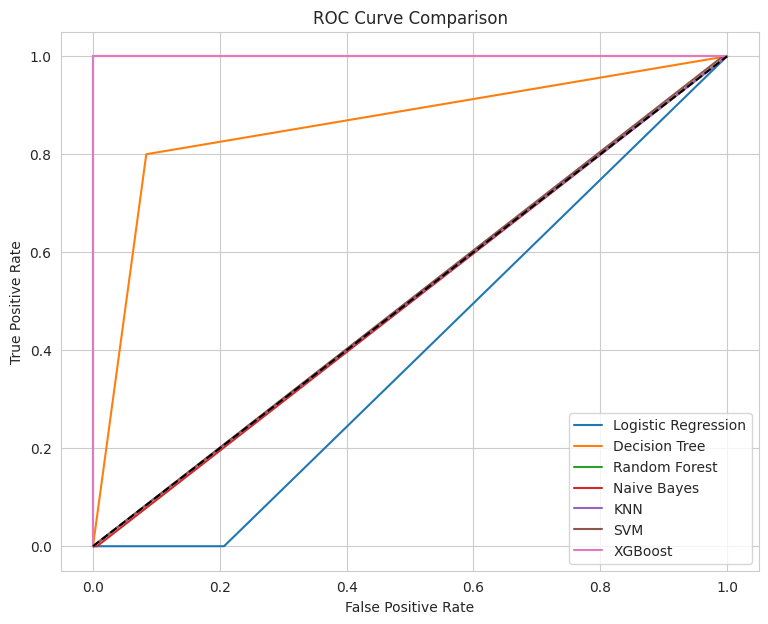

In [ ]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(9,7))

for model_name, model in trained_models.items():

    if model_name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:
        X_test_used = X_test_scaled
    else:
        X_test_used = X_test

    y_prob = model.predict_proba(X_test_used)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name}"
    )

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()



Decision Tree


,Feature,Importance
14,V14,0.945766
4,V4,0.049182
10,V10,0.002840
12,V12,0.001895
13,V13,0.000316
0,Time,0.000000
2,V2,0.000000
1,V1,0.000000
7,V7,0.000000
6,V6,0.000000


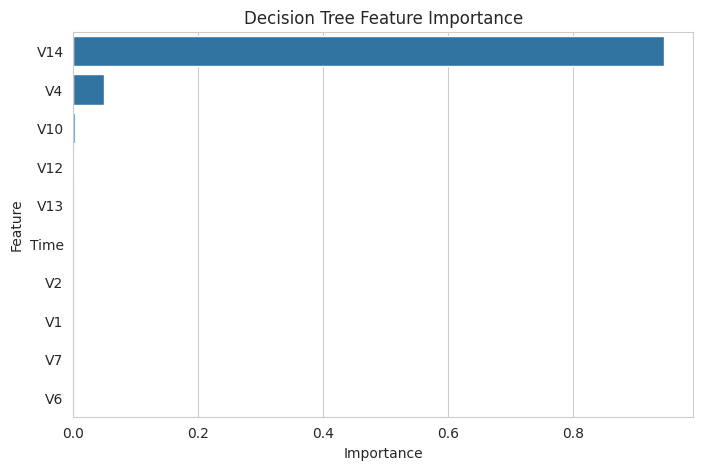



Random Forest


,Feature,Importance
14,V14,0.205015
12,V12,0.149981
10,V10,0.122208
11,V11,0.106781
4,V4,0.088353
3,V3,0.078858
6,V6,0.065702
17,V17,0.035558
16,V16,0.033267
2,V2,0.024013


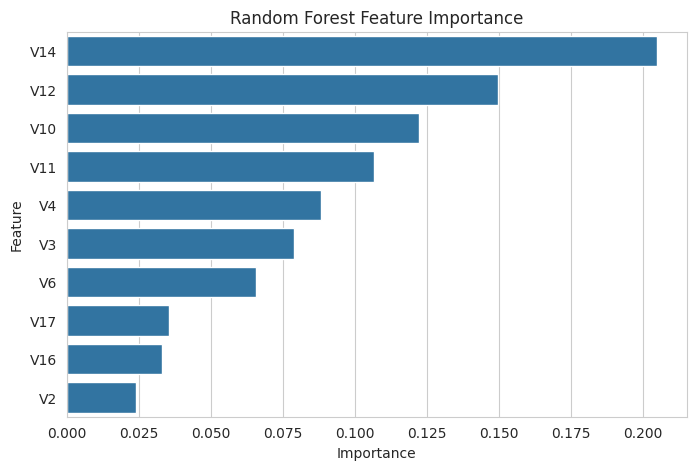



XGBoost


,Feature,Importance
14,V14,0.933133
4,V4,0.040537
12,V12,0.009716
10,V10,0.003617
20,V20,0.002135
9,V9,0.001969
23,V23,0.001723
29,Amount,0.001645
31,High_Amount,0.001140
17,V17,0.000734


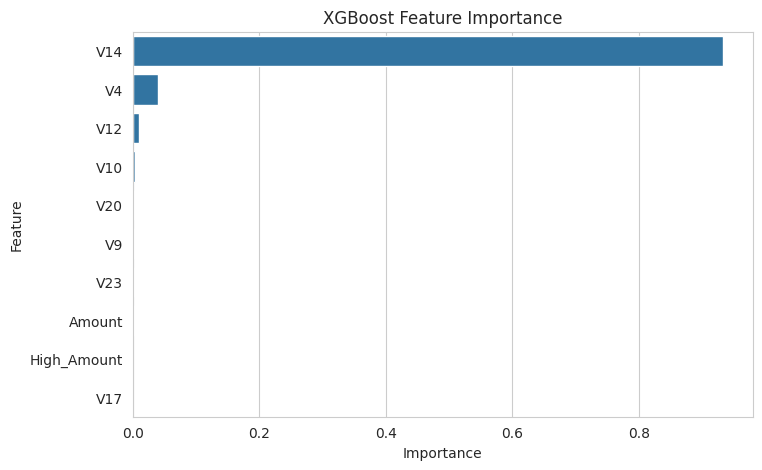

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

tree_models = [
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

for model_name in tree_models:

    model = trained_models[model_name]

    importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n")
    print("="*70)
    print(model_name)
    print("="*70)

    display(importance.head(10))

    plt.figure(figsize=(8,5))

    sns.barplot(

        data=importance.head(10),

        x="Importance",

        y="Feature"

    )

    plt.title(f"{model_name} Feature Importance")

    plt.show()

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

best_models = {}

HYPERPARAMETER TUNING


In [ ]:
# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_smote, y_train_smote)

best_models["Random Forest"] = rf_search.best_estimator_

print("\nBest Random Forest Parameters")
print(rf_search.best_params_)


Best Random Forest Parameters
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}


In [ ]:
# ------------------------------------------------------------
# SVM
# ------------------------------------------------------------

svm_params = {
    "C": [0.1, 1, 10, 50],
    "gamma": ["scale", "auto", 0.01, 0.001],
    "kernel": ["rbf"]
}

svm_search = RandomizedSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_distributions=svm_params,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

svm_search.fit(
    X_train_smote_scaled,
    y_train_smote
)

best_models["SVM"] = svm_search.best_estimator_

print("\nBest SVM Parameters")
print(svm_search.best_params_)


Best SVM Parameters
{'kernel': 'rbf', 'gamma': 0.01, 'C': 50}


In [ ]:
# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_params,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(
    X_train_smote,
    y_train_smote
)

best_models["XGBoost"] = xgb_search.best_estimator_

print("\nBest XGBoost Parameters")
print(xgb_search.best_params_)


Best XGBoost Parameters
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [ ]:
print("\n" + "=" * 70)
print("Hyperparameter Tuning Completed Successfully!")
print("=" * 70)


Hyperparameter Tuning Completed Successfully!


In [ ]:
# ============================================================
# EVALUATE TUNED MODELS
# ============================================================

print("=" * 70)
print("EVALUATING TUNED MODELS")
print("=" * 70)

tuned_results = []

for model_name, model in best_models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # ------------------------------------------------
    # Select Correct Test Data
    # ------------------------------------------------

    if model_name == "SVM":
        X_test_used = X_test_scaled
    else:
        X_test_used = X_test

    # ------------------------------------------------
    # Predictions
    # ------------------------------------------------

    y_pred = model.predict(X_test_used)
    y_prob = model.predict_proba(X_test_used)[:, 1]

    # ------------------------------------------------
    # Metrics
    # ------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

print("\nEvaluation Completed Successfully!")

EVALUATING TUNED MODELS

Random Forest

Confusion Matrix
[[1582    0]
 [   1    4]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1582
           1       1.00      0.80      0.89         5

    accuracy                           1.00      1587
   macro avg       1.00      0.90      0.94      1587
weighted avg       1.00      1.00      1.00      1587

Accuracy  : 0.9994
Precision : 1.0000
Recall    : 0.8000
F1 Score  : 0.8889
ROC AUC   : 1.0000

SVM

Confusion Matrix
[[1582    0]
 [   5    0]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1582
           1       0.00      0.00      0.00         5

    accuracy                           1.00      1587
   macro avg       0.50      0.50      0.50      1587
weighted avg       0.99      1.00      1.00      1587

Accuracy  : 0.9968
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.

In [ ]:
# ============================================================
# TUNED MODEL COMPARISON
# ============================================================

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

tuned_results_df = tuned_results_df.round(4)

print("=" * 70)
print("TUNED MODEL COMPARISON")
print("=" * 70)

display(tuned_results_df)

TUNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.9994,1.0000,0.8,0.8889,1.0000
1,XGBoost,0.9937,0.3333,1.0,0.5000,0.9999
2,SVM,0.9968,0.0000,0.0,0.0000,0.4981


In [ ]:
# ============================================================
# THRESHOLD OPTIMIZATION
# ============================================================

print("=" * 70)
print("THRESHOLD OPTIMIZATION")
print("=" * 70)

# Best tuned model
best_model = best_models["XGBoost"]

# Fraud probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

THRESHOLD OPTIMIZATION


,Threshold,Precision,Recall,F1 Score
0,0.10,0.021097,1.0,0.041322
1,0.15,0.021097,1.0,0.041322
2,0.20,0.021097,1.0,0.041322
3,0.25,0.050000,1.0,0.095238
4,0.30,0.083333,1.0,0.153846
5,0.35,0.166667,1.0,0.285714
6,0.40,0.263158,1.0,0.416667
7,0.45,0.294118,1.0,0.454545
8,0.50,0.333333,1.0,0.500000
9,0.55,0.333333,1.0,0.500000


In [ ]:
# ============================================================
# BEST THRESHOLD
# ============================================================

best_threshold = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("=" * 70)
print("BEST THRESHOLD")
print("=" * 70)

display(best_threshold)

BEST THRESHOLD


,15
Threshold,0.850000
Precision,0.625000
Recall,1.000000
F1 Score,0.769231


In [ ]:
# ============================================================
# FINAL EVALUATION USING BEST THRESHOLD
# ============================================================

best_threshold_value = best_threshold["Threshold"]

y_pred_final = (
    y_prob >= best_threshold_value
).astype(int)

print("Confusion Matrix")

print(confusion_matrix(
    y_test,
    y_pred_final
))

print()

print(classification_report(
    y_test,
    y_pred_final
))

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_final, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_final, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Confusion Matrix
[[1579    3]
 [   0    5]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1582
           1       0.62      1.00      0.77         5

    accuracy                           1.00      1587
   macro avg       0.81      1.00      0.88      1587
weighted avg       1.00      1.00      1.00      1587

Accuracy : 0.998109640831758
Precision: 0.625
Recall   : 1.0
F1 Score : 0.7692307692307693
ROC AUC  : 0.999873577749684


In [ ]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

import joblib

print("=" * 70)
print("SAVING FINAL MODEL")
print("=" * 70)

joblib.dump(best_model, "fraud_detector.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(best_threshold_value, "best_threshold.pkl")

print("Files Saved Successfully!")

print("\nSaved Files:")
print("- fraud_detector.pkl")
print("- scaler.pkl")
print("- best_threshold.pkl")

SAVING FINAL MODEL
Files Saved Successfully!

Saved Files:
- fraud_detector.pkl
- scaler.pkl
- best_threshold.pkl


In [ ]:
# ============================================================
# LOAD MODEL & MAKE PREDICTION
# ============================================================

loaded_model = joblib.load("fraud_detector.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_threshold = joblib.load("best_threshold.pkl")

sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

probability = loaded_model.predict_proba(sample_scaled)[0][1]

prediction = int(probability >= loaded_threshold)

print("=" * 70)
print("NEW TRANSACTION PREDICTION")
print("=" * 70)

print(f"Actual Class      : {y_test.iloc[0]}")
print(f"Fraud Probability : {probability:.4f}")
print(f"Prediction        : {prediction}")

NEW TRANSACTION PREDICTION
Actual Class      : 0
Fraud Probability : 0.0004
Prediction        : 0


In [ ]:
import sys
import sklearn
import pandas
import xgboost

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("xgboost:", xgboost.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
pandas: 2.2.2
xgboost: 3.3.0


In [ ]:
import joblib

model = joblib.load("fraud_detector.pkl")
print(type(model))

scaler = joblib.load("scaler.pkl")
print(type(scaler))

threshold = joblib.load("best_threshold.pkl")
print(threshold)

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>
0.8500000000000002


In [ ]:
import hashlib

with open("fraud_detector.pkl", "rb") as f:
    print(hashlib.md5(f.read()).hexdigest())

9228a896d054beb4f66e8254246d8e65


In [ ]:
import os

print("Size:", os.path.getsize("fraud_detector.pkl"), "bytes")

Size: 201296 bytes


In [ ]:
# Save XGBoost model in native format

best_model.save_model("fraud_detector.json")

# Save scaler and threshold

import joblib

joblib.dump(scaler, "scaler.pkl")

joblib.dump(best_threshold_value, "best_threshold.pkl")

['best_threshold.pkl']

In [ ]:
print(X_train.columns.tolist())
print("Total features:", len(X_train.columns))

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Log_Amount', 'High_Amount']
Total features: 32


In [ ]:
print(f"{amount_threshold:.10f}")

274.9000000000
